In [9]:
import kwant
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import eig
from scipy.optimize import fmin
import os
from matplotlib.colors import Normalize
from matplotlib.colors import TwoSlopeNorm
import scipy
from scipy.linalg import sqrtm
import scipy.linalg as la
import time
from tqdm.notebook import tqdm 


In [10]:
#function
def gr_zinengr(E, H, T, T_dx, Nd):
    I_nd = np.eye(Nd, dtype=complex)
    
    Tmat = np.block([
        [np.linalg.inv(T) @ (E - H), -np.linalg.inv(T) @ T.conj().T],
        [I_nd, np.zeros((Nd, Nd), dtype=complex)]
    ])

    eigvals, eigvecs = np.linalg.eig(Tmat)


    idx = np.argsort(np.abs(eigvals))
    eigvals = eigvals[idx]
    eigvecs = eigvecs[:, idx]

    S1 = eigvecs[:Nd, :Nd] 
    S2 = eigvecs[Nd:, :Nd]  

    g = np.linalg.inv(E - H - T @ S1 @ np.linalg.inv(S2))
    
    # 计算自能 Sigma
    Sigma = T_dx.conj().T @ g @ T_dx
    Gamma = 1j * (Sigma - Sigma.conj().T)
    return Sigma, Gamma

def Green_device_1(Nd, N, E, H, V, Sigma_r, Sigma_l):
    ALR = E - H
    
    # Gnn (从右向左递归)
    Gnn = np.zeros((N, Nd, Nd), dtype=complex)
    Gnn[N-1] = np.linalg.inv(ALR - Sigma_r)  # N-1 对应最右侧格点
    for n in range(N-2, 0, -1):              
        Gnn[n] = np.linalg.inv(ALR - V @ Gnn[n+1] @ V.conj().T)
    Gnn[0] = np.linalg.inv(ALR - V @ Gnn[1] @ V.conj().T - Sigma_l)
    
    # G1n 
    G1n = Gnn[0].copy()
    for n in range(1, N):
        G1n = G1n @ V @ Gnn[n]
        
    # Gnn2 (从左向右递归)
    Gnn2 = np.zeros((N, Nd, Nd), dtype=complex)
    Gnn2[0] = np.linalg.inv(ALR - Sigma_l)
    for n in range(1, N-1):
        Gnn2[n] = np.linalg.inv(ALR - V.conj().T @ Gnn2[n-1] @ V)
    Gnn2[N-1] = np.linalg.inv(ALR - V.conj().T @ Gnn2[N-2] @ V - Sigma_r)
    
    # Gn1
    Gn1 = Gnn2[N-1].copy()
    for n in range(N-2, -1, -1):
        Gn1 = Gn1 @ V.conj().T @ Gnn2[n]

    #Gnn2[N-1] (右下角)，Gnn[0] (左上角)，G1n (右上角)，Gn1 (左下角)

    return Gnn, G1n, Gnn2, Gn1



In [5]:
#function直接求逆，加随机数
def gr_L(T_l, A_l, check_tol=1e-6):

    N = T_l.shape[0]
    I = np.eye(N)
    Tmat = np.block([
        [np.linalg.inv(T_l) @ A_l, -np.linalg.inv(T_l) @ T_l.conj().T],
        [I, np.zeros((N, N))]
    ])

    eigvals, eigvecs = eig(Tmat)


    idx = np.argsort(np.abs(eigvals))
    eigvals = eigvals[idx]
    eigvecs = eigvecs[:, idx]

    lambdas = eigvals[:N]
    vecs = eigvecs[:, :N]

    S1 = vecs[:N, :] 
    S2 = vecs[N:, :]  

    gL = np.linalg.inv(A_l - T_l @ S1 @ np.linalg.inv(S2))
    check = (A_l - T_l @ gL @ T_l.conj().T) @ gL - I
    max_err = np.max(np.abs(check))

    return gL

def zinengr_L(T_LD_wei ,gr_L_wei):
    return T_LD_wei.conj().T @ gr_L_wei @ T_LD_wei

def Gr_DD(shuijishu_set ,H_q,H_l,H_r,  T_12,T_LD,T_l,T_RD,T_r,  N,E,eta=1e-6):
    d = H_q.shape[0]
    I = np.eye(d, dtype=complex)
    Z = np.zeros((d, d), dtype=complex)

    EI_gai = np.block([
        [(E + 1j*eta)*s0, np.zeros((2,2))],
        [np.zeros((2,2)), (E + 1j*eta)*s0]
    ])

    A_l = EI_gai - H_l
    gcl = gr_L(T_l, A_l)
    Sigma_L = zinengr_L(T_LD, gcl)

    A_r = EI_gai - H_r
    gcr = gr_L(T_r, A_r)
    Sigma_R = zinengr_L(T_RD, gcr)


    A_DD = [[Z.copy() for _ in range(N)] for _ in range(N)]

    for i in range(N):

        if i == 0:
            A_DD[i][i] = EI_gai - H_q - Sigma_L
        elif i == N-1:
            A_DD[i][i] = EI_gai - H_q - Sigma_R
        else:
            A_DD[i][i] = EI_gai - H_q

        if i < N-1:
            A_DD[i][i+1] = -T_12

        if i > 0:
            A_DD[i][i-1] = -T_12.conj().T
    A_DD = np.block(A_DD)
    G_DD_r = np.linalg.inv(A_DD)
    return G_DD_r , G_DD_r[0:4, 0:4] ,Sigma_R ,Sigma_L 

def Gr_DD_suiji(suijishu_set, H_q, H_l, H_r, T_12, T_LD, T_l, T_RD, T_r, N, E, eta=1e-6):

    d = H_q.shape[0]
    I = np.eye(d, dtype=complex)
    Z = np.zeros((d, d), dtype=complex)

    # 构造复能量矩阵
    s0 = np.eye(2, dtype=complex)
    EI_gai = np.block([
        [(E + 1j*eta)*s0, np.zeros((2,2))],
        [np.zeros((2,2)), (E + 1j*eta)*s0]
    ])

    # --- 计算左右引线自能 (保持不变) ---
    A_l = EI_gai - H_l
    gcl = gr_L(T_l, A_l)
    Sigma_L = zinengr_L(T_LD, gcl)

    A_r = EI_gai - H_r
    gcr = gr_L(T_r, A_r)
    Sigma_R = zinengr_L(T_RD, gcr)

    # --- 生成这一组特有的 N 个随机化学势波动 ---
    # np.random.uniform(low, high, size) 生成均匀分布的随机数
    V_rand_array = np.random.uniform(suijishu_set[0], suijishu_set[1], N)

    A_DD = [[Z.copy() for _ in range(N)] for _ in range(N)]

    for i in range(N):
        # 取出第 i 个格点的随机化学势波动
        V_i = V_rand_array[i]
        
        # 构造随机化学势矩阵：电子部分 +V_i，空穴部分 -V_i
        V_rand_matrix = np.diag([V_i, V_i, -V_i, -V_i])

        # 把随机矩阵加入到对角块中
        if i == 0:
            A_DD[i][i] = EI_gai - H_q - V_rand_matrix - Sigma_L
        elif i == N-1:
            A_DD[i][i] = EI_gai - H_q - V_rand_matrix - Sigma_R
        else:
            A_DD[i][i] = EI_gai - H_q - V_rand_matrix

        # 非对角跳跃项保持不变
        if i < N-1:
            A_DD[i][i+1] = -T_12
        if i > 0:
            A_DD[i][i-1] = -T_12.conj().T
            
    # 组装成完整的大矩阵并求逆
    A_DD = np.block(A_DD)
    G_DD_r = np.linalg.inv(A_DD)
    
    # 按照原函数的返回值格式返回
    return G_DD_r, G_DD_r[0:4, 0:4], Sigma_R, Sigma_L

In [5]:
#验证
if 3==2:
    N=2
    _,G_11,Sigma_r3,_= Gr_DD(H_q,H_l,H_r,  T_12,T_LD,T_l,T_RD,T_r,  N,0,eta=1e-8)
    E_mat = (0 + 1j *1e-8) * np.eye(4, dtype=complex)
    Sigma_r, Gamma_r = gr_zinengr(E_mat, H_r,T_r, T_RD, 4)
    Sigma_l, Gamma_l = gr_zinengr(E_mat, H_l,T_l, T_LD, 4)
    Gnn, G1n, Gnn2, Gn1 = Green_device_1(4, N, E_mat, H_q, T_12, Sigma_r, Sigma_l)
    #print(G_11)
    #print(Gnn[0])
    #print(Sigma_r)
    #print(Sigma_r3)


In [6]:
#参数 NS 我的
dela = 1
chaodaojiao = 0
a=1
t =200
af =50
mu = 0
tc=1

#左边
hx=4   #0.5
hz=0 #0.95
#(my = 0.954776)
saimanjiao = np.pi*0

#右边
mx=-10 #0.5
mz=0  #0.95
zhongjian_saimanjiao=np.pi*0
af2=0
U_c=0

T_Tc=1e-4
Delta = dela#* np.tanh(1.74 * np.sqrt(1 / T_Tc - 1))

N=2
q=0
dianshubei=0.2#8
KBT=2 * dela * T_Tc / 3.5
shumu=int(np.floor(50*dela/(2*np.pi*KBT)))*dianshubei

#矩阵信息
sx = np.array([[0, 1], [1, 0]], complex)
sy = np.array([[0, -1j], [1j, 0]], complex)
sz = np.array([[1, 0], [0, -1]], complex)
s0 = np.array([[1, 0], [0, 1]], complex)

def H_onsite(mx,mz,Bjiao,weizhi,chaodaojiao,renyixiang=0):
    if weizhi==2:
        Delta_X=np.zeros((2,2))
        HX_block=(U_c-(mu-2*t))*s0 + mx*np.sin(Bjiao)*sy + mz*sz +mx*np.cos(Bjiao)*sx
    elif weizhi==3:
        Delta_X= Delta * np.exp(-1j*chaodaojiao) * 1j * sy
        HX_block=-(mu-2*t)*s0 + mx*np.sin(Bjiao)*sy + mz*sz +mx*np.cos(Bjiao)*sx
    return np.block([
        [ HX_block,        Delta_X       ],
        [ Delta_X.conj().T, -HX_block.conj() ]
    ])
def H_hop(af,t):
    H_X_right_to_left_hop_block=-1*(t*s0+1j*af*sz/(1*a))
    return np.block([
        [ H_X_right_to_left_hop_block,        np.zeros((2,2))],
        [ np.zeros((2,2)), -H_X_right_to_left_hop_block.conj() ]
    ])
#左边矩阵信息
H_L_onsite=H_onsite(mx,mz,zhongjian_saimanjiao,2,chaodaojiao,t)
H_L_right_to_left_hop=H_hop(af2*af,t)

#中间矩阵信息
H_center_to_L=H_hop(af2*af,t*tc)

H_center=H_onsite(mx,mz,zhongjian_saimanjiao,2,chaodaojiao,t)
H_center_right_to_left_hop=H_hop(af2*af,t)

H_R_to_center=H_hop(0,t*tc)

#右边矩阵信息
H_R_onsite=H_onsite(hx,hz,saimanjiao,3,chaodaojiao,t)
H_R_right_to_left_hop=H_hop(af,t)


#输入矩阵
H_q=H_center
T_12= H_center_right_to_left_hop

H_l= H_L_onsite
T_l= H_L_right_to_left_hop

H_r= H_R_onsite
T_r=H_R_right_to_left_hop.conj().T

T_LD=H_center_to_L.conj().T
T_RD= H_R_to_center




Calculating Energy Points:   0%|          | 0/201 [00:00<?, ?it/s]

Elapsed time: 0.12 seconds


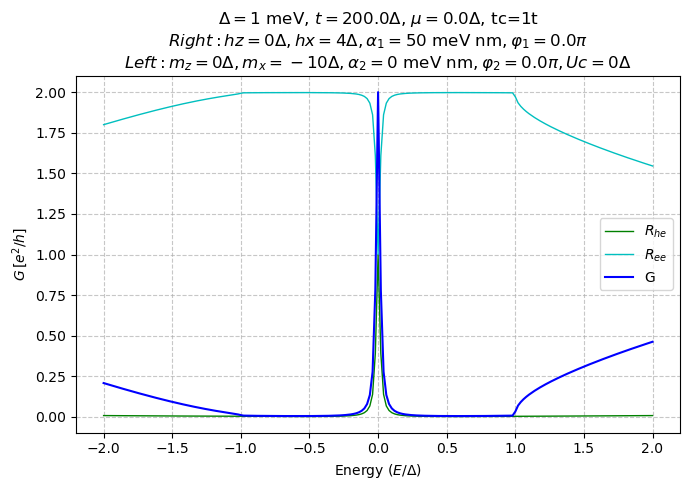

In [7]:
# 计时开始 #E变 R
start_time = time.time()
#N= 2 #
N=N#int(np.floor(2 * 10**3 * 1 / a))
Mdata = 201
Energy = np.linspace(-2, 2, Mdata)
#Energy = np.linspace(-1, 1, Mdata)
G = np.zeros(Mdata, dtype=float)
Ree_set = np.zeros(Mdata, dtype=float)
Rhe_set = np.zeros(Mdata, dtype=float)
Nd=4
# tqdm 将在 Jupyter 中显示进度条
for n in tqdm(range(Mdata), desc="Calculating Energy Points"):
    ep = Energy[n] * dela
    E_mat = (ep + 1j *1e-8) * np.eye(4, dtype=complex)

    # 计算电极格林函数
    Sigma_r, Gamma_r = gr_zinengr(E_mat, H_r,T_r, T_RD, Nd)
    Sigma_l, Gamma_l = gr_zinengr(E_mat, H_l,T_l, T_LD, Nd)
    #Sigma_r, Gamma_r = Green_lead_1(Nd, E_mat, H_r, T_r, T_RD)
    #Sigma_l, Gamma_l = Green_lead_1(Nd, E_mat, H_l, T_l, T_LD)

    # 提取电子与空穴块
    Gamma_ee_l = Gamma_l[0:2, 0:2]
    #Gamma_ee_r = Gamma_r[0:2, 0:2]
    Gamma_hh_l = Gamma_l[2:4, 2:4]
    #Gamma_hh_r = Gamma_r[2:4, 2:4]

    sqrt_Gamma_ee_l = scipy.linalg.sqrtm(Gamma_ee_l)
    sqrt_Gamma_hh_l = scipy.linalg.sqrtm(Gamma_hh_l)

    Gnn, G1n, Gnn2, Gn1 = Green_device_1(Nd, N, E_mat, H_q, T_12, Sigma_r, Sigma_l)
    
  # 提取首端格林函数
    GLL = Gnn[0]
    GLL_ee = GLL[0:2, 0:2]
    GLL_he = GLL[2:4, 0:2]
    
    # 5. 计算散射矩阵元
    S_LL_ee = -1 * np.eye(2) + 1j * sqrt_Gamma_ee_l @ GLL_ee @ sqrt_Gamma_ee_l
    S_LL_he = 1j * sqrt_Gamma_hh_l @ GLL_he @ sqrt_Gamma_ee_l

    # 6. 计算反射概率 (核心修复：R_he 矩阵乘法修正)
    R_ee = np.real(np.trace(S_LL_ee.conj().T @ S_LL_ee))
    R_he = np.real(np.trace(S_LL_he.conj().T @ S_LL_he)) # <--- 修正了原来的 S_LL_ee
    
    # 7. 最终电导计算 (固定入射通道数 N=2)
    Rhe_set[n]=R_he
    Ree_set[n]=R_ee 
    G[n] = 2 - R_ee + R_he

# 输出耗时
print(f"Elapsed time: {time.time() - start_time:.2f} seconds")



plt.figure(figsize=(7, 5))
plt.plot(Energy, Rhe_set, 'g-', linewidth=1, label='$R_{he}$') # 'g' for green
plt.plot(Energy, Ree_set, 'c-', linewidth=1, label='$R_{ee}$') # 'b' for blue
plt.plot(Energy, G, 'b-', linewidth=1.5, label='G')             # 'c' for cyan
plt.xlabel(r'Energy ($E/\Delta$)')
plt.ylabel(r'$G \, [e^2/h]$')

plt.title(
    fr'$\Delta = {dela}$ meV, $t = {t/dela}\Delta$, $\mu = {mu/dela}\Delta$, tc={tc}t' + '\n' +
    fr'$Right: hz = {hz}\Delta, hx = {hx}\Delta, \alpha_1 = {af}\text{{ meV nm}}, \varphi_1 = {saimanjiao}\pi$' + '\n' +
    fr'$Left: m_z = {mz}\Delta, m_x = {mx}\Delta, \alpha_2 = {af*af2}\text{{ meV nm}}, \varphi_2 = {zhongjian_saimanjiao}\pi, Uc={U_c}\Delta$'
)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.tight_layout()
#plt.ylim(-0.1,1.1)
plt.show()



In [8]:
#参数 SESARs
dela = 1
chaodaojiao = 0
a=1
af =2
a=0.1
mu = 0
tc=15

#右边S
tr=25
hx=0   #0.5
hz=2 #0.95
#(my = 0.954776)
saimanjiao = np.pi*0

#左边N
tl=30
mx=0 #0.5
mz=0  #0.95
zhongjian_saimanjiao=np.pi*0
af2=0
U_c=-0.3


Delta = dela#* np.tanh(1.74 * np.sqrt(1 / T_Tc - 1))


#矩阵信息
sx = np.array([[0, 1], [1, 0]], complex)
sy = np.array([[0, -1j], [1j, 0]], complex)
sz = np.array([[1, 0], [0, -1]], complex)
s0 = np.array([[1, 0], [0, 1]], complex)

def H_onsite(mx,mz,Bjiao,weizhi,chaodaojiao,t,renyixiang=0):
    if weizhi==2:
        Delta_X=np.zeros((2,2))
        HX_block=(U_c-(mu-2*t))*s0 + mx*np.sin(Bjiao)*sy + mz*sz +mx*np.cos(Bjiao)*sx
    elif weizhi==3:
        Delta_X= Delta * np.exp(-1j*chaodaojiao) * 1j * sy
        HX_block=-(mu-2*t)*s0 + mx*np.sin(Bjiao)*sy + mz*sz +mx*np.cos(Bjiao)*sx
    return np.block([
        [ HX_block,        Delta_X       ],
        [ Delta_X.conj().T, -HX_block.conj() ]
    ])
def H_hop(af,t):
    H_X_right_to_left_hop_block=-1*(t*s0+1j*af*sy/(2*a))
    return np.block([
        [ H_X_right_to_left_hop_block,        np.zeros((2,2))],
        [ np.zeros((2,2)), -H_X_right_to_left_hop_block.conj() ]
    ])
#左边矩阵信息
H_L_onsite=H_onsite(mx,mz,zhongjian_saimanjiao,2,chaodaojiao,tl)
H_L_right_to_left_hop=H_hop(af2*af,tl)

#中间矩阵信息
H_center_to_L=H_hop(af2*af,tl)

H_center=H_onsite(mx,mz,zhongjian_saimanjiao,2,chaodaojiao,tl)
H_center_right_to_left_hop=H_hop(af2*a,tl)

H_R_to_center=H_hop(0,tc)

#右边矩阵信息
H_R_onsite=H_onsite(hx,hz,saimanjiao,3,chaodaojiao,tr)
H_R_right_to_left_hop=H_hop(af,tr)


#输入矩阵
H_q=H_center
T_12= H_center_right_to_left_hop

H_l= H_L_onsite
T_l= H_L_right_to_left_hop

H_r= H_R_onsite
T_r=H_R_right_to_left_hop.conj().T

T_LD=H_center_to_L.conj().T
T_RD= H_R_to_center




Calculating Energy Points:   0%|          | 0/301 [00:00<?, ?it/s]

Elapsed time: 0.10 seconds


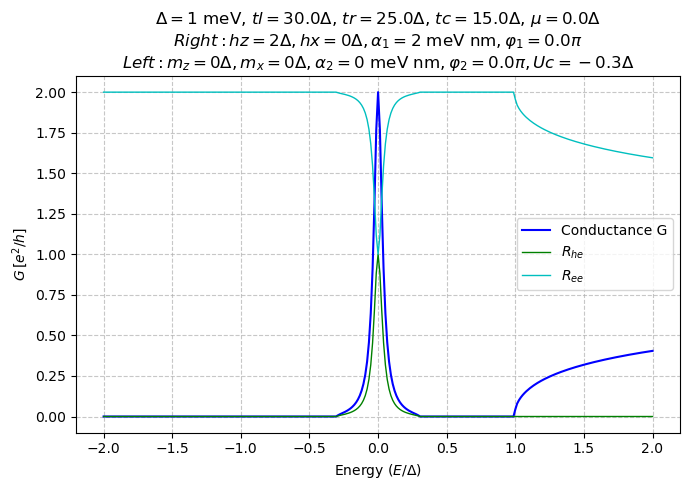

In [89]:
# 计时开始 #E变 R
start_time = time.time()
#N= 2 #
N=2#int(np.floor(2 * 10**3 * 1 / a))
Mdata = 301
Energy = np.linspace(-2, 2, Mdata)
#Energy = np.linspace(-1, 1, Mdata)
G = np.zeros(Mdata, dtype=float)
Ree_set = np.zeros(Mdata, dtype=float)
Rhe_set = np.zeros(Mdata, dtype=float)
Nd=4
# tqdm 将在 Jupyter 中显示进度条
for n in tqdm(range(Mdata), desc="Calculating Energy Points"):
    ep = Energy[n] * dela
    E_mat = (ep + 1j *1e-8) * np.eye(4, dtype=complex)

    # 计算电极格林函数
    Sigma_r, Gamma_r = gr_zinengr(E_mat, H_r,T_r, T_RD, Nd)
    Sigma_l, Gamma_l = gr_zinengr(E_mat, H_l,T_l, T_LD, Nd)
    #Sigma_r, Gamma_r = Green_lead_1(Nd, E_mat, H_r, T_r, T_RD)
    #Sigma_l, Gamma_l = Green_lead_1(Nd, E_mat, H_l, T_l, T_LD)

    # 提取电子与空穴块
    Gamma_ee_l = Gamma_l[0:2, 0:2]
    Gamma_ee_r = Gamma_r[0:2, 0:2]
    Gamma_hh_l = Gamma_l[2:4, 2:4]
    Gamma_hh_r = Gamma_r[2:4, 2:4]

    sqrt_Gamma_ee_l = scipy.linalg.sqrtm(Gamma_ee_l)
    sqrt_Gamma_hh_l = scipy.linalg.sqrtm(Gamma_hh_l)

    Gnn, G1n, Gnn2, Gn1 = Green_device_1(Nd, N, E_mat, H_q, T_12, Sigma_r, Sigma_l)
    
  # 提取首端格林函数
    GLL = Gnn[0]
    GLL_ee = GLL[0:2, 0:2]
    GLL_he = GLL[2:4, 0:2]
    #GLL_he = GLL[0:2, 2:4]

    # 5. 计算散射矩阵元
    S_LL_ee = -1 * np.eye(2) + 1j * sqrt_Gamma_ee_l @ GLL_ee @ sqrt_Gamma_ee_l
    S_LL_he = 1j * sqrt_Gamma_hh_l @ GLL_he @ sqrt_Gamma_ee_l

    # 6. 计算反射概率 (核心修复：R_he 矩阵乘法修正)
    R_ee = np.real(np.trace(S_LL_ee.conj().T @ S_LL_ee))
    R_he = np.real(np.trace(S_LL_he.conj().T @ S_LL_he)) # <--- 修正了原来的 S_LL_ee

    # 7. 最终电导计算 (固定入射通道数=2)
    Rhe_set[n]=R_he
    Ree_set[n]=R_ee 
    G[n] = 2 - R_ee + R_he

# 输出耗时
print(f"Elapsed time: {time.time() - start_time:.2f} seconds")



plt.figure(figsize=(7, 5))
plt.plot(Energy, G, 'b-', linewidth=1.5, label='Conductance G')
plt.plot(Energy, Rhe_set, 'g-', linewidth=1, label='$R_{he}$') # 'g' for green
plt.plot(Energy, Ree_set, 'c-', linewidth=1, label='$R_{ee}$') # 'b' for blue
plt.xlabel(r'Energy ($E/\Delta$)')
plt.ylabel(r'$G \, [e^2/h]$')

plt.title(
    fr'$\Delta = {dela}$ meV, $tl = {tl/dela}\Delta$, $tr = {tr/dela}\Delta$, $tc = {tc/dela}\Delta$, $\mu = {mu/dela}\Delta$' + '\n' +
    fr'$Right: hz = {hz}\Delta, hx = {hx}\Delta, \alpha_1 = {af}\text{{ meV nm}}, \varphi_1 = {saimanjiao}\pi$' + '\n' +
    fr'$Left: m_z = {mz}\Delta, m_x = {mx}\Delta, \alpha_2 = {af*af2}\text{{ meV nm}}, \varphi_2 = {zhongjian_saimanjiao}\pi, Uc={U_c}\Delta$'
)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.tight_layout()
#plt.ylim(-0.1,1.1)
plt.show()

